In [1]:
print("hi")

hi


In [28]:
from pathlib import Path
import json
import os
import warnings

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")
warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)


In [29]:
ROOT = Path.cwd()
RACE_RESULTS_PATH = ROOT / "session_model_data" / "race_results.csv"
LAP_FEATURES_PATH = ROOT / "module_2_lap_time_prediction_V2" / "data" / "lap_time_features.csv"
ARTIFACTS_DIR = ROOT / "artifacts"

OUTPUT_RECOMMENDATIONS_PATH = ARTIFACTS_DIR / "module_4_pit_strategy_recommendations.csv"
OUTPUT_DEGRADATION_PATH = ARTIFACTS_DIR / "module_4_tire_degradation_trends.csv"
OUTPUT_METRICS_PATH = ARTIFACTS_DIR / "module_4_pit_strategy_metrics.json"
OUTPUT_MODEL_PATH = ARTIFACTS_DIR / "module_4_finish_position_model.joblib"


In [30]:
RACE_LAPS = {
    "Australian Grand Prix": 58,
    "Azerbaijan Grand Prix": 51,
    "Bahrain Grand Prix": 57,
    "Chinese Grand Prix": 56,
    "Emilia Romagna Grand Prix": 63,
    "Japanese Grand Prix": 53,
    "Miami Grand Prix": 57,
    "Saudi Arabian Grand Prix": 50,
}

PIT_LOSS_SECONDS = {
    "Australian Grand Prix": 22.0,
    "Azerbaijan Grand Prix": 20.0,
    "Bahrain Grand Prix": 23.0,
    "Chinese Grand Prix": 22.0,
    "Emilia Romagna Grand Prix": 25.0,
    "Japanese Grand Prix": 21.5,
    "Miami Grand Prix": 22.0,
    "Saudi Arabian Grand Prix": 21.0,
}

In [31]:
race_results = pd.read_csv(RACE_RESULTS_PATH)
lap_features = pd.read_csv(LAP_FEATURES_PATH)

print("Race results shape:", race_results.shape)
print("Lap features shape:", lap_features.shape)

display(race_results.head())
display(lap_features.head())

Race results shape: (400, 10)
Lap features shape: (13116, 26)


,season,round,race_name,race_date,circuit,driver,team,grid_position,finish_position,winner
0,2022,1,Bahrain Grand Prix,2022-03-20,Bahrain International Circuit,LEC,Ferrari,1,1,1
1,2022,1,Bahrain Grand Prix,2022-03-20,Bahrain International Circuit,SAI,Ferrari,3,2,0
2,2022,1,Bahrain Grand Prix,2022-03-20,Bahrain International Circuit,HAM,Mercedes,5,3,0
3,2022,1,Bahrain Grand Prix,2022-03-20,Bahrain International Circuit,RUS,Mercedes,9,4,0
4,2022,1,Bahrain Grand Prix,2022-03-20,Bahrain International Circuit,MAG,Haas F1 Team,7,5,0


,driver_number,lap_number,session_elapsed_seconds,lap_time_seconds,pit_out,pit_in,speed_i1,speed_i2,speed_finish_line,speed_trap,driver,team,season,event_name,circuit,country,session_name,session_type,track_status,previous_lap_seconds,rolling_3_lap_median,previous_speed_i1,previous_speed_i2,previous_speed_finish_line,previous_speed_trap,driver_session_lap_index
0,23,4,1371.702,85.268,False,False,270.0,313.0,293.0,304.0,ALB,Williams,2022,Australian Grand Prix,Melbourne,Australia,Practice 1,Practice,1,87.522,87.522,267.0,310.0,292.0,295.0,2
1,23,6,1566.254,84.483,False,False,272.0,314.0,295.0,310.0,ALB,Williams,2022,Australian Grand Prix,Melbourne,Australia,Practice 1,Practice,1,85.268,86.395,270.0,313.0,293.0,304.0,3
2,23,8,1784.359,98.773,False,False,235.0,157.0,293.0,313.0,ALB,Williams,2022,Australian Grand Prix,Melbourne,Australia,Practice 1,Practice,1,84.483,85.268,272.0,314.0,295.0,310.0,4
3,23,9,1868.699,84.340,False,False,273.0,297.0,294.0,306.0,ALB,Williams,2022,Australian Grand Prix,Melbourne,Australia,Practice 1,Practice,1,98.773,85.268,235.0,157.0,293.0,313.0,5
4,23,13,2912.559,83.377,False,False,273.0,311.0,296.0,307.0,ALB,Williams,2022,Australian Grand Prix,Melbourne,Australia,Practice 1,Practice,1,84.340,84.483,273.0,297.0,294.0,306.0,6


In [32]:
def estimate_degradation_trends(lap_features):
    laps = lap_features.copy()
    laps["lap_time_seconds"] = pd.to_numeric(laps["lap_time_seconds"], errors="coerce")
    laps["driver_session_lap_index"] = pd.to_numeric(
        laps["driver_session_lap_index"], errors="coerce"
    )

    laps = laps.dropna(
        subset=[
            "season",
            "event_name",
            "session_name",
            "driver",
            "lap_time_seconds",
            "driver_session_lap_index",
        ]
    )
    laps = laps.loc[laps["lap_time_seconds"].between(45, 180)]
    laps = laps.loc[laps["driver_session_lap_index"].between(1, 25)]

    session_slopes = []
    group_cols = ["season", "event_name", "session_name", "driver"]

    for keys, group in laps.groupby(group_cols):
        group = group.sort_values("driver_session_lap_index")
        if len(group) < 4:
            continue

        q_low, q_high = group["lap_time_seconds"].quantile([0.10, 0.90])
        clean = group.loc[group["lap_time_seconds"].between(q_low, q_high)]

        if len(clean) < 4 or clean["driver_session_lap_index"].nunique() < 4:
            continue

        slope, intercept = np.polyfit(
            clean["driver_session_lap_index"].to_numpy(),
            clean["lap_time_seconds"].to_numpy(),
            1,
        )

        if np.isfinite(slope):
            season, event_name, session_name, driver = keys
            session_slopes.append(
                {
                    "season": season,
                    "event_name": event_name,
                    "session_name": session_name,
                    "driver": driver,
                    "session_degradation_sec_per_lap": float(np.clip(slope, -0.35, 0.90)),
                    "sample_laps": int(len(clean)),
                    "baseline_lap_seconds": float(intercept),
                }
            )

    slopes = pd.DataFrame(session_slopes)

    degradation = (
        slopes.groupby("event_name", as_index=False)
        .agg(
            event_degradation_sec_per_lap=("session_degradation_sec_per_lap", "median"),
            degradation_sample_sessions=("session_degradation_sec_per_lap", "size"),
            median_baseline_lap_seconds=("baseline_lap_seconds", "median"),
        )
        .sort_values("event_name")
    )
    degradation["event_degradation_sec_per_lap"] = degradation[
        "event_degradation_sec_per_lap"
    ].clip(lower=0.015, upper=0.45)

    return degradation


degradation = estimate_degradation_trends(lap_features)

display(degradation.sort_values("event_degradation_sec_per_lap", ascending=False))

,event_name,event_degradation_sec_per_lap,degradation_sample_sessions,median_baseline_lap_seconds
7,Saudi Arabian Grand Prix,0.336761,195,91.544967
0,Australian Grand Prix,0.291250,215,80.986600
2,Bahrain Grand Prix,0.265496,165,96.169051
5,Japanese Grand Prix,0.231391,67,91.739776
3,Chinese Grand Prix,0.126045,92,97.814373
6,Miami Grand Prix,0.017375,157,92.575723
1,Azerbaijan Grand Prix,0.015000,42,106.227930
4,Emilia Romagna Grand Prix,0.015000,67,82.696646


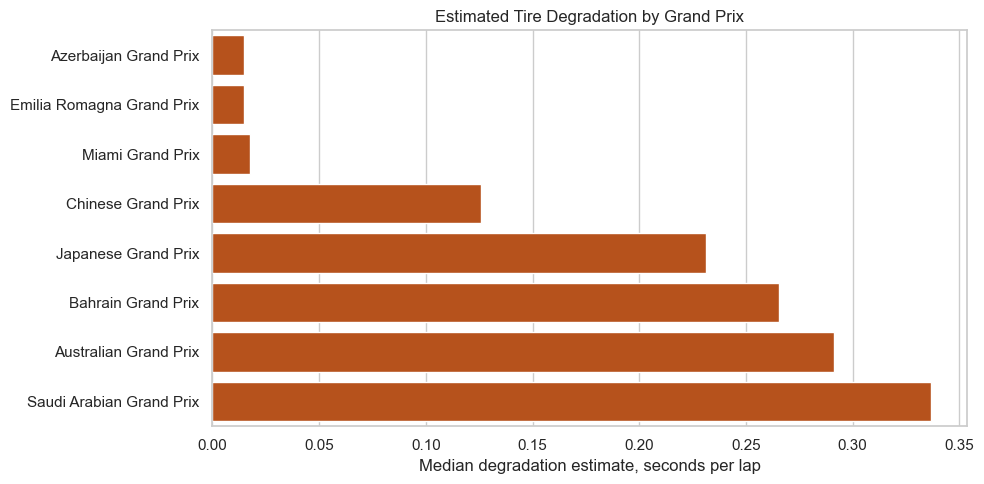

In [33]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=degradation.sort_values("event_degradation_sec_per_lap"),
    x="event_degradation_sec_per_lap",
    y="event_name",
    color="#d04a02",
)
plt.title("Estimated Tire Degradation by Grand Prix")
plt.xlabel("Median degradation estimate, seconds per lap")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [37]:
def add_prior_strength_features(race_results):
    races = race_results.copy()
    races["grid_position"] = pd.to_numeric(races["grid_position"], errors="coerce")
    races["finish_position"] = pd.to_numeric(races["finish_position"], errors="coerce")
    if "points" not in races.columns:
        races["points"] = 0
    races["points"] = pd.to_numeric(races["points"], errors="coerce").fillna(0)

    races = races.dropna(subset=["season", "round", "driver", "team", "finish_position"])
    races = races.sort_values(["season", "round", "driver"]).reset_index(drop=True)

    races["field_size"] = races.groupby(["season", "round"])["driver"].transform("nunique")

    for entity in ["driver", "team"]:
        races[f"{entity}_prior_avg_finish"] = (
            races.groupby(entity)["finish_position"]
            .transform(lambda values: values.shift().expanding().mean())
        )
        races[f"{entity}_prior_points"] = (
            races.groupby(entity)["points"]
            .transform(lambda values: values.shift().expanding().mean())
        )

    fallback_finish = races["finish_position"].mean()
    fallback_points = races["points"].mean()

    races["driver_prior_avg_finish"] = races["driver_prior_avg_finish"].fillna(fallback_finish)
    races["team_prior_avg_finish"] = races["team_prior_avg_finish"].fillna(fallback_finish)
    races["driver_prior_points"] = races["driver_prior_points"].fillna(fallback_points)
    races["team_prior_points"] = races["team_prior_points"].fillna(fallback_points)

    return races

In [38]:
def build_model_table(race_results, degradation):
    table = add_prior_strength_features(race_results)
    table = table.merge(
        degradation,
        left_on="race_name",
        right_on="event_name",
        how="left",
    )

    fallback_degradation = degradation["event_degradation_sec_per_lap"].median()
    if not np.isfinite(fallback_degradation):
        fallback_degradation = 0.08

    table["event_degradation_sec_per_lap"] = table[
        "event_degradation_sec_per_lap"
    ].fillna(float(fallback_degradation))

    return table

In [ ]:
model_table = build_model_table(race_results, degradation)

display(model_table[[
    "season",
    "round",
    "race_name",
    "driver",
    "team",
    "grid_position",
    "driver_prior_avg_finish",
    "team_prior_avg_finish",
    "event_degradation_sec_per_lap",
    "finish_position",
]].head())

,season,round,race_name,driver,team,grid_position,driver_prior_avg_finish,team_prior_avg_finish,event_degradation_sec_per_lap,finish_position
0,2022,1,Bahrain Grand Prix,ALB,Williams,14,10.4525,10.4525,0.265496,13
1,2022,1,Bahrain Grand Prix,ALO,Alpine F1 Team,8,10.4525,10.4525,0.265496,9
2,2022,1,Bahrain Grand Prix,BOT,Alfa Romeo,6,10.4525,10.4525,0.265496,6
3,2022,1,Bahrain Grand Prix,GAS,AlphaTauri,10,10.4525,10.4525,0.265496,20
4,2022,1,Bahrain Grand Prix,HAM,Mercedes,5,10.4525,10.4525,0.265496,3


In [40]:
MODEL_FEATURES = [
    "season",
    "round",
    "grid_position",
    "field_size",
    "driver_prior_avg_finish",
    "team_prior_avg_finish",
    "driver_prior_points",
    "team_prior_points",
    "event_degradation_sec_per_lap",
    "race_name",
    "team",
    "driver",
]

In [41]:
NUMERIC_FEATURES = [
    "season",
    "round",
    "grid_position",
    "field_size",
    "driver_prior_avg_finish",
    "team_prior_avg_finish",
    "driver_prior_points",
    "team_prior_points",
    "event_degradation_sec_per_lap",
]

CATEGORICAL_FEATURES = ["race_name", "team", "driver"]

In [42]:
def make_finish_position_model():
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                NUMERIC_FEATURES,
            ),
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    min_frequency=2,
                    sparse_output=False,
                ),
                CATEGORICAL_FEATURES,
            ),
        ]
    )

    model = HistGradientBoostingRegressor(
        learning_rate=0.06,
        max_iter=250,
        l2_regularization=0.10,
        random_state=42,
    )

    return Pipeline(steps=[("preprocess", preprocessor), ("model", model)])

In [43]:
def evaluate_model(table):
    valid = table.dropna(subset=MODEL_FEATURES + ["finish_position"]).copy()
    groups = valid["season"].astype(str) + "_" + valid["round"].astype(str)
    n_splits = min(5, groups.nunique())

    finish_model = make_finish_position_model()
    splitter = GroupKFold(n_splits=n_splits)

    predictions = cross_val_predict(
        finish_model,
        valid[MODEL_FEATURES],
        valid["finish_position"],
        cv=splitter,
        groups=groups,
    )

    return {
        "mae": float(mean_absolute_error(valid["finish_position"], predictions)),
        "r2": float(r2_score(valid["finish_position"], predictions)),
        "rows": int(len(valid)),
        "group_folds": int(n_splits),
    }

In [ ]:
metrics = evaluate_model(model_table)
finish_model = make_finish_position_model()
finish_model.fit(model_table[MODEL_FEATURES], model_table["finish_position"])

print(json.dumps(metrics, indent=2))

{
  "mae": 3.9081679641019673,
  "r2": 0.24955748857309823,
  "rows": 400,
  "group_folds": 5
}


In [45]:
def candidate_strategy_time(
    race_laps,
    pit_lap,
    degradation_rate,
    grid_position,
    field_size,
    pit_loss_seconds,
):
    first_stint = pit_lap
    second_stint = race_laps - pit_lap

    degradation_seconds = degradation_rate * (
        first_stint * (first_stint - 1) / 2
        + second_stint * (second_stint - 1) / 2
    )

    grid_norm = (grid_position - 1) / max(field_size - 1, 1)
    traffic_penalty = 18.0 * grid_norm * (pit_lap / race_laps)
    clean_air_credit = -4.0 * (1.0 - grid_norm) * (pit_lap / race_laps)

    tire_stress = np.clip((degradation_rate - 0.06) / 0.14, 0, 1)
    ideal_stint = race_laps * (0.56 - 0.09 * tire_stress)
    longest_stint = max(first_stint, second_stint)
    cliff_penalty = max(0.0, longest_stint - ideal_stint) ** 2 * degradation_rate * 0.18

    return float(
        degradation_seconds
        + pit_loss_seconds
        + traffic_penalty
        + clean_air_credit
        + cliff_penalty
    )


In [46]:
def recommend_for_race(table, model, season=None, round_number=None):
    if season is None or round_number is None:
        target_key = (
            table[["season", "round"]]
            .drop_duplicates()
            .sort_values(["season", "round"])
            .iloc[-1]
        )
        season = int(target_key["season"])
        round_number = int(target_key["round"])

    race = table.loc[(table["season"] == season) & (table["round"] == round_number)].copy()
    if race.empty:
        raise ValueError(f"No race found for season={season}, round={round_number}")

    race_name = race["race_name"].iloc[0]
    race_laps = RACE_LAPS.get(race_name, 57)
    pit_loss = PIT_LOSS_SECONDS.get(race_name, 22.0)

    min_pit_lap = max(8, int(race_laps * 0.28))
    max_pit_lap = min(race_laps - 8, int(race_laps * 0.72))

    race["baseline_finish_prediction"] = model.predict(race[MODEL_FEATURES])

    recommendations = []

    for _, row in race.iterrows():
        degradation_rate = float(row["event_degradation_sec_per_lap"])
        candidates = []

        for pit_lap in range(min_pit_lap, max_pit_lap + 1):
            strategy_seconds = candidate_strategy_time(
                race_laps=race_laps,
                pit_lap=pit_lap,
                degradation_rate=degradation_rate,
                grid_position=float(row["grid_position"]),
                field_size=int(row["field_size"]),
                pit_loss_seconds=pit_loss,
            )
            candidates.append((pit_lap, strategy_seconds))

        best_lap, best_strategy_seconds = min(candidates, key=lambda item: item[1])
        candidate_table = pd.DataFrame(candidates, columns=["pit_lap", "strategy_seconds"])
        near_best = candidate_table.loc[
            candidate_table["strategy_seconds"] <= best_strategy_seconds + 1.0,
            "pit_lap",
        ]

        strategy_position_penalty = best_strategy_seconds / 18.0

        recommendations.append(
            {
                "season": int(row["season"]),
                "round": int(row["round"]),
                "race_name": race_name,
                "driver": row["driver"],
                "team": row["team"],
                "grid_position": int(row["grid_position"]),
                "race_laps": race_laps,
                "suggested_pit_lap": int(best_lap),
                "pit_window_start": int(near_best.min()),
                "pit_window_end": int(near_best.max()),
                "event_degradation_sec_per_lap": degradation_rate,
                "strategy_time_score_seconds": round(best_strategy_seconds, 3),
                "baseline_finish_prediction": float(row["baseline_finish_prediction"]),
                "optimized_rank_score": float(
                    row["baseline_finish_prediction"] + strategy_position_penalty
                ),
            }
        )

    recommendations = pd.DataFrame(recommendations)
    recommendations["predicted_finishing_position"] = (
        recommendations["optimized_rank_score"].rank(method="first").astype(int)
    )

    return recommendations.sort_values("predicted_finishing_position").reset_index(drop=True)

In [47]:
TARGET_SEASON = None
TARGET_ROUND = None

recommendations = recommend_for_race(
    model_table,
    finish_model,
    season=TARGET_SEASON,
    round_number=TARGET_ROUND,
)

final_columns = [
    "season",
    "round",
    "race_name",
    "driver",
    "team",
    "grid_position",
    "suggested_pit_lap",
    "pit_window_start",
    "pit_window_end",
    "predicted_finishing_position",
]

display(recommendations[final_columns])

,season,round,race_name,driver,team,grid_position,suggested_pit_lap,pit_window_start,pit_window_end,predicted_finishing_position
0,2025,5,Saudi Arabian Grand Prix,PIA,McLaren,2,25,24,26,1
1,2025,5,Saudi Arabian Grand Prix,LEC,Ferrari,4,25,24,26,2
2,2025,5,Saudi Arabian Grand Prix,VER,Red Bull,1,25,24,26,3
3,2025,5,Saudi Arabian Grand Prix,RUS,Mercedes,3,25,24,26,4
4,2025,5,Saudi Arabian Grand Prix,NOR,McLaren,10,25,24,26,5
5,2025,5,Saudi Arabian Grand Prix,ANT,Mercedes,5,25,24,26,6
6,2025,5,Saudi Arabian Grand Prix,SAI,Williams,6,25,24,26,7
7,2025,5,Saudi Arabian Grand Prix,HAM,Ferrari,7,25,24,26,8
8,2025,5,Saudi Arabian Grand Prix,ALB,Williams,11,25,24,26,9
9,2025,5,Saudi Arabian Grand Prix,ALO,Aston Martin,13,25,24,26,10


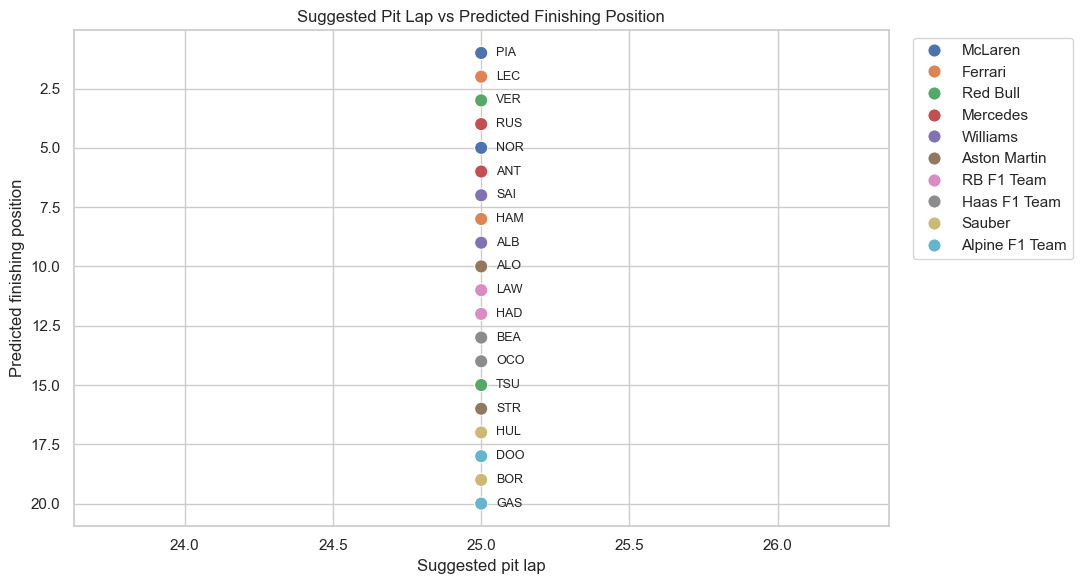

In [48]:
plt.figure(figsize=(11, 6))
plot_data = recommendations.sort_values("predicted_finishing_position")

sns.scatterplot(
    data=plot_data,
    x="suggested_pit_lap",
    y="predicted_finishing_position",
    hue="team",
    s=90,
)

for _, row in plot_data.iterrows():
    plt.text(
        row["suggested_pit_lap"] + 0.05,
        row["predicted_finishing_position"],
        row["driver"],
        fontsize=9,
        va="center",
    )

plt.gca().invert_yaxis()
plt.title("Suggested Pit Lap vs Predicted Finishing Position")
plt.xlabel("Suggested pit lap")
plt.ylabel("Predicted finishing position")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [49]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

recommendations.to_csv(OUTPUT_RECOMMENDATIONS_PATH, index=False)
degradation.to_csv(OUTPUT_DEGRADATION_PATH, index=False)
joblib.dump(finish_model, OUTPUT_MODEL_PATH)

with OUTPUT_METRICS_PATH.open("w") as file:
    json.dump(metrics, file, indent=2)


In [50]:
print("Saved recommendations:", OUTPUT_RECOMMENDATIONS_PATH)
print("Saved degradation trends:", OUTPUT_DEGRADATION_PATH)
print("Saved model:", OUTPUT_MODEL_PATH)
print("Saved metrics:", OUTPUT_METRICS_PATH)

Saved recommendations: /Users/santhoshkumarv/vs_code_projects/internship-harshith/projects/capstone_project/artifacts/module_4_pit_strategy_recommendations.csv
Saved degradation trends: /Users/santhoshkumarv/vs_code_projects/internship-harshith/projects/capstone_project/artifacts/module_4_tire_degradation_trends.csv
Saved model: /Users/santhoshkumarv/vs_code_projects/internship-harshith/projects/capstone_project/artifacts/module_4_finish_position_model.joblib
Saved metrics: /Users/santhoshkumarv/vs_code_projects/internship-harshith/projects/capstone_project/artifacts/module_4_pit_strategy_metrics.json


In [51]:
final_output = recommendations[[
    "race_name",
    "driver",
    "team",
    "suggested_pit_lap",
    "pit_window_start",
    "pit_window_end",
    "predicted_finishing_position",
]].copy()

display(final_output)

,race_name,driver,team,suggested_pit_lap,pit_window_start,pit_window_end,predicted_finishing_position
0,Saudi Arabian Grand Prix,PIA,McLaren,25,24,26,1
1,Saudi Arabian Grand Prix,LEC,Ferrari,25,24,26,2
2,Saudi Arabian Grand Prix,VER,Red Bull,25,24,26,3
3,Saudi Arabian Grand Prix,RUS,Mercedes,25,24,26,4
4,Saudi Arabian Grand Prix,NOR,McLaren,25,24,26,5
5,Saudi Arabian Grand Prix,ANT,Mercedes,25,24,26,6
6,Saudi Arabian Grand Prix,SAI,Williams,25,24,26,7
7,Saudi Arabian Grand Prix,HAM,Ferrari,25,24,26,8
8,Saudi Arabian Grand Prix,ALB,Williams,25,24,26,9
9,Saudi Arabian Grand Prix,ALO,Aston Martin,25,24,26,10
